In [1]:
import pandas as pd
import numpy as np
import json
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from pytorch_lightning import seed_everything
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seed = 42
seed_everything(seed)

/home/teresa/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 42


42

In [2]:
# load df from after feature selection
model_df = pd.read_csv("data/model_df.csv")

X = model_df.drop(columns=["AI_exposure"])
Y = model_df["AI_exposure"]

# 60/20/20 train/val/test split
X_train_val, X_test, Y_train_val, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, test_size=0.25, random_state=42)

# load feature groups
with open("feature_groups.json", "r") as f:
    feature_groups = json.load(f)

# create a dictionary to store the models
models = {}

## Models

### Baseline: mean predictor
We establish the mean predictor baseline as a sanity check for the performance of our models. Any model should beat this baseline.

In [3]:
mean_pred = np.ones(len(Y_test)) * Y_train.mean()
baseline_mse = mean_squared_error(Y_test, mean_pred)
baseline_rmse = np.sqrt(baseline_mse)
print(f"Baseline RMSE: {baseline_rmse:.4f}")

Baseline RMSE: 0.0249


## Linear Regression
We first train linear regression without regularization. Then, since we want to investigate which features contribute the most to the prediction, we train Lasso regression and intepret the sparse weight vector.

In [4]:
# linear regression
linear_model = LinearRegression()
linear_model.fit(X_train, Y_train)
linear_pred_train = linear_model.predict(X_train)
linear_pred_test = linear_model.predict(X_test)
linear_mse_train = mean_squared_error(Y_train, linear_pred_train)
linear_mse_test = mean_squared_error(Y_test, linear_pred_test)
linear_rmse_train = np.sqrt(linear_mse_train)
linear_rmse_test = np.sqrt(linear_mse_test)
print(f"Linear Regression train RMSE: {linear_rmse_train:.4f}")
print(f"Linear Regression test RMSE: {linear_rmse_test:.4f}")

# lasso regression
alpha_list = [1e-5, 1e-4, 1e-3]
for alpha in alpha_list:
    lasso_model = Lasso(alpha=alpha)
    lasso_model.fit(X_train, Y_train)
    lasso_pred_train = lasso_model.predict(X_train)
    lasso_pred_test = lasso_model.predict(X_test)
    lasso_mse_train = mean_squared_error(Y_train, lasso_pred_train)
    lasso_mse_test = mean_squared_error(Y_test, lasso_pred_test)
    lasso_rmse_train = np.sqrt(lasso_mse_train)
    lasso_rmse_test = np.sqrt(lasso_mse_test)
    print(f"\nalpha: {alpha}")
    print(f"Lasso Regression train RMSE: {lasso_rmse_train:.4f}")
    print(f"Lasso Regression test RMSE: {lasso_rmse_test:.4f}")

    # use sparse weight vector to interpret features
    lasso_coef = lasso_model.coef_
    non_zero_coef_idx = np.where(lasso_coef != 0)[0]
    non_zero_coef_features = X.columns[non_zero_coef_idx]
    print(f"Number of non-zero coefficients: {len(non_zero_coef_idx)}")
    print(f"Features contributing to prediction: {non_zero_coef_features.tolist()}")

Linear Regression train RMSE: 0.0242
Linear Regression test RMSE: 0.0242

alpha: 1e-05
Lasso Regression train RMSE: 0.0242
Lasso Regression test RMSE: 0.0242
Number of non-zero coefficients: 19
Features contributing to prediction: ['pct_service', 'pct_sales_office', 'pct_natural_resources_construction', 'pct_industry_agriculture', 'pct_industry_construction', 'pct_industry_manufacturing', 'pct_industry_finance', 'pct_industry_professional', 'pct_industry_education_healthcare', 'pct_industry_arts_food', 'pct_private_forprofit', 'pct_nonprofit', 'pct_self_employed_unincorporated', 'pct_bachelors_plus', 'per_capita_income', 'pct_drove_alone', 'pct_public_transit', 'pct_broadband', 'pct_long_commute']

alpha: 0.0001
Lasso Regression train RMSE: 0.0244
Lasso Regression test RMSE: 0.0243
Number of non-zero coefficients: 4
Features contributing to prediction: ['pct_industry_manufacturing', 'pct_bachelors_plus', 'per_capita_income', 'pct_drove_alone']

alpha: 0.001
Lasso Regression train RMSE:

## Random forest
With an ensemble model like Random Forest, we are able to gain insight on feature importance.

In [5]:
num_tree = 10
max_depth = 5
min_samples_split = 2
min_samples_leaf = 2

rf_model = RandomForestRegressor(
    n_estimators=num_tree,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf
)
rf_model.fit(X_train, Y_train)
rf_pred_train = rf_model.predict(X_train)
rf_pred_test = rf_model.predict(X_test)
rf_mse_train = mean_squared_error(Y_train, rf_pred_train)
rf_mse_test = mean_squared_error(Y_test, rf_pred_test)
rf_rmse_train = np.sqrt(rf_mse_train)
rf_rmse_test = np.sqrt(rf_mse_test)

print(f"Random Forest Train RMSE: {rf_rmse_train:.4f}")
print(f"Random Forest Test RMSE: {rf_rmse_test:.4f}")

Random Forest Train RMSE: 0.0241
Random Forest Test RMSE: 0.0242


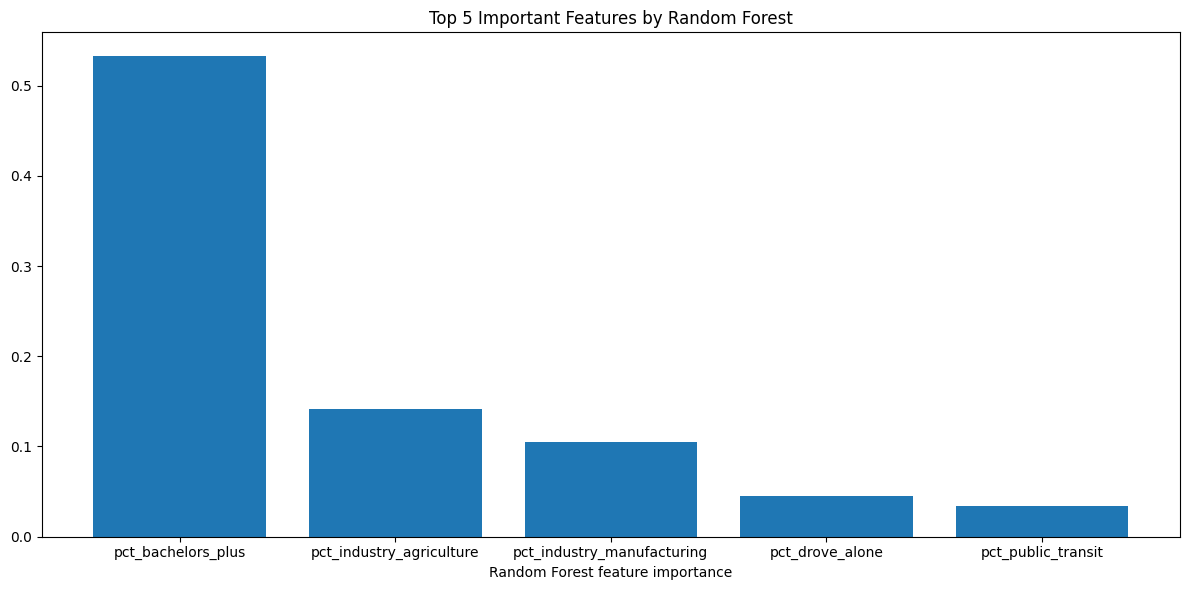

In [6]:
importances = rf_model.feature_importances_
importance_sorted_idx = np.argsort(importances)[::-1]
k = 5
top_k_idx = importance_sorted_idx[:k]
top_k_features = X.columns[top_k_idx]

plt.figure(figsize=(12, 6))
plt.bar(top_k_features, importances[top_k_idx])
plt.xlabel("Random Forest feature importance")
plt.title(f"Top {k} Important Features by Random Forest")
plt.tight_layout()
plt.show()

In [7]:
rf_importance_df = pd.DataFrame({
    "feature": X.columns[importance_sorted_idx],
    "importance": importances[importance_sorted_idx],
})

rf_importance_df.to_csv("data/rf_feature_importance.csv", index=False)

## MLP
Comparing the performance of MLP with linear models, we can see if nonlinear relationships are important for this regression task.

In [8]:
X_train_t = torch.tensor(X_train.to_numpy(), dtype=torch.float32, device=device)
Y_train_t = torch.tensor(Y_train.to_numpy().reshape(-1, 1), dtype=torch.float32, device=device)
X_val_t = torch.tensor(X_val.to_numpy(), dtype=torch.float32, device=device)
Y_val_t = torch.tensor(Y_val.to_numpy().reshape(-1, 1), dtype=torch.float32, device=device)
X_test_t = torch.tensor(X_test.to_numpy(), dtype=torch.float32, device=device)
Y_test_t = torch.tensor(Y_test.to_numpy().reshape(-1, 1), dtype=torch.float32, device=device)

train_ds = TensorDataset(X_train_t, Y_train_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super(MLP, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_dim, hidden_dim))
        for _ in range(num_layers - 1):
            self.layers.append(nn.Linear(hidden_dim, hidden_dim))
        self.output_layer = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        for layer in self.layers:
            x = nn.ReLU()(layer(x))
        return self.output_layer(x)

def train_mlp(input_dim, hidden_dim, num_layers, lr, epochs):
    model = MLP(input_dim, hidden_dim, num_layers).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    model.train()
    for _ in range(epochs):
        for x, y in train_loader:
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
    
    model.eval()
    with torch.no_grad():
        pred_val = model(X_val_t).squeeze(1).cpu().numpy()
        mse_val = mean_squared_error(Y_val.to_numpy(), pred_val)
        rmse_val = np.sqrt(mse_val)
    return rmse_val

# tune mlp
lr_list = [1e-3, 1e-4, 1e-5]
num_layers_list = [2, 3, 4]
hidden_dim_list = [32, 64, 128, 256]

n_trials = 10

best_params = {
    "lr": 1e-3,
    "hidden_dim": 128,
    "num_layers": 2
}

best_val_rmse = float('inf')
input_dim = X_train.shape[1]
epochs = 100

for trial in range(n_trials):
    lr = random.choice(lr_list)
    hidden_dim = random.choice(hidden_dim_list)
    num_layers = random.choice(num_layers_list)

    rmse_val = train_mlp(input_dim, hidden_dim, num_layers, lr, epochs)

    print(
        f"Trial {trial + 1}/{n_trials}: "
        f"lr={lr}, hidden_dim={hidden_dim}, "
        f"num_layers={num_layers}, val_rmse={rmse_val:.4f}"
    )

    if rmse_val < best_val_rmse:
        best_val_rmse = rmse_val
        best_params = {
            "lr": lr,
            "hidden_dim": hidden_dim,
            "num_layers": num_layers
        }

lr_best = best_params["lr"]
hidden_dim_best = best_params["hidden_dim"]
num_layers_best = best_params["num_layers"]

print(f"Best hyperparameters: lr={lr_best}, hidden_dim={hidden_dim_best}, num_layers={num_layers_best}")
print(f"Best validation RMSE: {best_val_rmse:.4f}")

Trial 1/10: lr=1e-05, hidden_dim=32, num_layers=2, val_rmse=0.0351
Trial 2/10: lr=1e-05, hidden_dim=128, num_layers=2, val_rmse=0.0459
Trial 3/10: lr=0.001, hidden_dim=64, num_layers=4, val_rmse=0.0249
Trial 4/10: lr=0.001, hidden_dim=32, num_layers=4, val_rmse=0.0253
Trial 5/10: lr=0.0001, hidden_dim=32, num_layers=2, val_rmse=0.2380
Trial 6/10: lr=0.001, hidden_dim=64, num_layers=2, val_rmse=4.7487
Trial 7/10: lr=1e-05, hidden_dim=32, num_layers=4, val_rmse=0.0445
Trial 8/10: lr=0.001, hidden_dim=256, num_layers=2, val_rmse=0.0540
Trial 9/10: lr=0.0001, hidden_dim=128, num_layers=2, val_rmse=1.2495
Trial 10/10: lr=0.001, hidden_dim=256, num_layers=3, val_rmse=0.0252
Best hyperparameters: lr=0.001, hidden_dim=64, num_layers=4
Best validation RMSE: 0.0249


In [9]:
# train and test mlp with all selected features on best set of hyperparameters
def train_test_mlp(input_dim, hidden_dim, num_layers, lr, epochs):
    model = MLP(input_dim, hidden_dim, num_layers).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    model.train()
    for _ in range(epochs):
        for x, y in train_loader:
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
    
    model.eval()
    with torch.no_grad():
        pred_test = model(X_test_t).squeeze(1).cpu().numpy()
        mse_test = mean_squared_error(Y_test.to_numpy(), pred_test)
        rmse_test = np.sqrt(mse_test)
    return rmse_test

mlp_rmse_test = train_test_mlp(input_dim, hidden_dim_best, num_layers_best, lr_best, epochs)
print(f"MLP Test RMSE: {mlp_rmse_test:.4f}")

MLP Test RMSE: 0.0249


In [10]:
# MLP for each feature group
group_names = []
rmse_values = []

# save original all-feature tensors/loaders
train_loader_full = train_loader
X_test_t_full = X_test_t
for group_name, features in feature_groups.items():
    print(f"Train MLP for feature group: {group_name}")
    X_train_group = X_train[features]
    X_test_group = X_test[features]
    X_train_group_t = torch.tensor(X_train_group.to_numpy(), dtype=torch.float32, device=device)
    X_test_group_t = torch.tensor(X_test_group.to_numpy(), dtype=torch.float32, device=device)
    train_group_ds = TensorDataset(X_train_group_t, Y_train_t)
    train_loader = DataLoader(train_group_ds, batch_size=256, shuffle=True)
    X_test_t = X_test_group_t
    test_rmse = train_test_mlp(
        input_dim=len(features),
        hidden_dim=hidden_dim_best,
        num_layers=num_layers_best,
        lr=lr_best,
        epochs=epochs
    )
    group_names.append(group_name)
    rmse_values.append(test_rmse)
    print(f"MLP on {group_name}, Test RMSE: {test_rmse:.4f}\n")

Train MLP for feature group: occupation


MLP on occupation, Test RMSE: 0.0249

Train MLP for feature group: industry
MLP on industry, Test RMSE: 0.0249

Train MLP for feature group: employment_type
MLP on employment_type, Test RMSE: 0.0249

Train MLP for feature group: education_income
MLP on education_income, Test RMSE: 0.0279

Train MLP for feature group: commute
MLP on commute, Test RMSE: 0.0249

Train MLP for feature group: digital_access
MLP on digital_access, Test RMSE: 0.0249



In [11]:
model_results_df = pd.DataFrame([
    {
        "model": "Linear Regression",
        "test_rmse": linear_rmse_test,
    },
    {
        "model": "Lasso alpha=1e-5",
        "test_rmse": lasso_rmse_test,
    },
    {
        "model": "Random Forest",
        "test_rmse": rf_rmse_test,
    },
    {
        "model": "MLP",
        "test_rmse": mlp_rmse_test,
    },
])

model_results_df.to_csv("data/model_results.csv", index=False)